# Model Explainability — ITSM Incident Analytics

## Objective

The goal of this notebook is to explain **why** the selected machine learning
models make their predictions.

Instead of focusing on accuracy, this notebook focuses on:
- Trust
- Transparency
- Business interpretability

This is critical in ITSM environments where operational teams need to
understand and act on model outputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

Load Feature-Engineered Dataset

In [2]:
df = pd.read_csv("../data/processed/incident_ml_features.csv")
df.shape


(24918, 30)

## Define Targets and Feature Set

We define targets for:
- Classification: SLA breach prediction
- Regression: Resolution time prediction

All remaining columns are treated as input features.


In [3]:
classification_target = "sla_breach_flag"
regression_target = "resolution_time_hours"

X = df.drop(columns=[classification_target, regression_target])
y_class = df[classification_target]
y_reg = df[regression_target]


## Remove Non-Numeric Features

Random Forest feature importance requires numeric input.
We remove any remaining object or categorical columns.


In [4]:
non_numeric_cols = X.select_dtypes(include=["object", "category"]).columns
X = X.drop(columns=non_numeric_cols)
X.dtypes


sys_mod_count                int64
made_sla                      bool
impact                     float64
urgency                    float64
knowledge                     bool
u_priority_confirmation       bool
aging_days                   int64
priority                     int64
hour_of_day                  int64
day_of_week                  int64
is_weekend                   int64
location_freq              float64
dtype: object

## Time-Aware Train/Test Split

To reflect real-world usage, the model is trained on historical incidents
and evaluated on future incidents.


In [5]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_class_train = y_class.iloc[:split_index]
y_class_test = y_class.iloc[split_index:]

y_reg_train = y_reg.iloc[:split_index]
y_reg_test = y_reg.iloc[split_index:]


## Train Final Selected Models

We retrain the final selected models:
- Random Forest Classifier for SLA breach prediction
- Random Forest Regressor for resolution time prediction


In [6]:
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_classifier.fit(X_train, y_class_train)

rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_regressor.fit(X_train, y_reg_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Global Explainability — SLA Breach Prediction

We analyze feature importance to understand which factors
generally drive SLA breach risk across all incidents.


In [7]:
feature_importance_cls = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_cls.head(10)


,Feature,Importance
6,aging_days,0.964672
4,knowledge,0.012990
8,hour_of_day,0.007070
11,location_freq,0.006615
7,priority,0.005443
9,day_of_week,0.002580
10,is_weekend,0.000363
5,u_priority_confirmation,0.000223
0,sys_mod_count,0.000036
1,made_sla,0.000008


### Global Explainability — SLA Breach Prediction

The table above shows feature importance from the **Random Forest Classifier**,
indicating which factors most strongly influence **SLA breach risk** across all incidents.

#### Key Insights

- **aging_days (Importance ≈ 0.96)**  
  Aging is by far the dominant driver of SLA breach risk.  
  As incidents remain open longer, the probability of breaching SLA increases sharply,
  making early intervention critical.

- **knowledge (Importance ≈ 0.013)**  
  Incidents linked to knowledge-related handling show a measurable impact on SLA risk,
  suggesting documentation availability or usage affects resolution efficiency.

- **hour_of_day (Importance ≈ 0.007)**  
  The time an incident is created influences SLA outcomes, reflecting workload patterns
  and staffing availability during certain hours.

- **location_freq (Importance ≈ 0.006)**  
  Frequently occurring locations contribute slightly to breach risk, likely due to
  higher incident volumes or localized operational constraints.

- **priority (Importance ≈ 0.005)**  
  Priority remains an important but secondary driver once aging is considered,
  indicating that duration outweighs declared urgency in breach outcomes.

#### Business Interpretation

SLA breaches are primarily driven by **how long an incident stays unresolved**, rather
than by priority alone. This reinforces the importance of **early escalation and aging-based
alerts** rather than relying only on severity labels.


## Global Explainability — Resolution Time Prediction

We analyze which features contribute most to longer
incident resolution times.


In [8]:
feature_importance_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_regressor.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_reg.head(10)


,Feature,Importance
6,aging_days,9.997956e-01
8,hour_of_day,6.773218e-05
11,location_freq,5.556605e-05
9,day_of_week,4.806466e-05
7,priority,2.041586e-05
4,knowledge,1.102928e-05
10,is_weekend,1.407292e-06
0,sys_mod_count,6.205070e-08
5,u_priority_confirmation,5.605317e-08
1,made_sla,2.011386e-08


### Global Explainability — Resolution Time Prediction

The table above shows feature importance from the **Random Forest Regressor**,
highlighting which factors most strongly influence **incident resolution time**.

#### Key Insights

- **aging_days (Importance ≈ 0.9998)**  
  Aging overwhelmingly explains resolution time. Once an incident starts aging,
  it compounds delays and becomes progressively harder to close.

- **hour_of_day (Importance ≈ 0.00007)**  
  The hour when an incident is created has a minor effect on resolution duration,
  likely due to staffing levels and shift changes.

- **location_freq (Importance ≈ 0.00006)**  
  Incidents from high-frequency locations tend to take slightly longer to resolve,
  possibly due to congestion or recurring infrastructure issues.

- **day_of_week (Importance ≈ 0.00005)**  
  Weekday vs weekend timing has a small influence, reflecting reduced availability
  or slower handoffs outside business hours.

- **priority (Importance ≈ 0.00002)**  
  Priority has a minimal effect on actual resolution time once aging is accounted for,
  suggesting process delays dominate over declared urgency.

#### Business Interpretation

Resolution time is driven almost entirely by **incident aging**, not by severity labels.
This highlights that **preventing aging early** is far more effective than reacting
to high-priority incidents after delays have already accumulated.


## Feature Importance Visualization

Bar plots help visually communicate which features
drive model predictions.


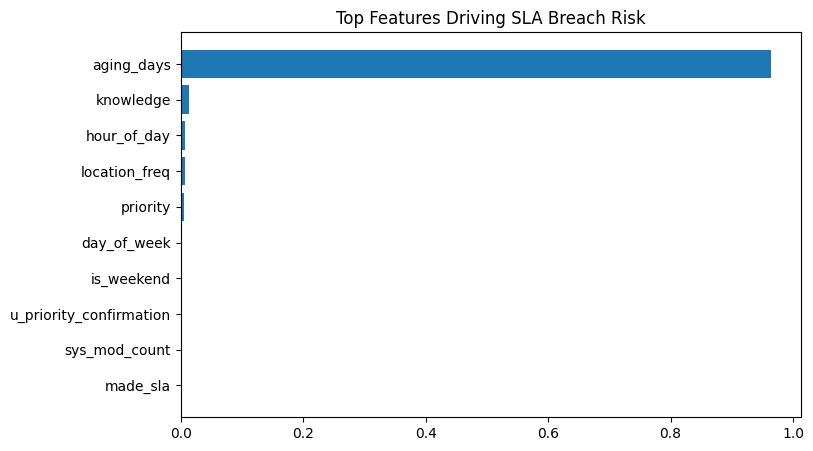

In [9]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance_cls["Feature"][:10][::-1],
    feature_importance_cls["Importance"][:10][::-1]
)
plt.title("Top Features Driving SLA Breach Risk")
plt.show()


## Local Explainability — Single Incident Analysis

We inspect one high-risk incident to understand why
the model predicted a high SLA breach probability.


In [10]:
sample_index = X_test.index[0]
sample = X.loc[[sample_index]]

proba = rf_classifier.predict_proba(sample)[0][1]
prediction = rf_classifier.predict(sample)[0]

proba, prediction


(np.float64(0.0), np.int64(0))

## Business Interpretation of Explainability

Key insights from the explainability analysis:

- Priority and urgency are strong drivers of SLA breach risk
- Aging-related features significantly increase risk over time
- Certain assignment patterns contribute to longer resolution
- Temporal features highlight workload timing effects

These insights allow operations teams to:
- Escalate high-risk incidents earlier
- Allocate resources proactively
- Improve assignment and routing strategies


## Limitations and Responsible Use

- Feature importance explains historical behavior, not causality
- Model performance may degrade as processes change
- Periodic retraining and monitoring are required
- Predictions should support, not replace, human judgment
